# Calidad del Vino — Proyecto de Clasificación Multiclase Ordinal
**Autor**: Miguel Pajuelo Gómez  

**Grado**: Ingeniería Matemática e Inteligencia Artificial


En este proyecto se realiza un análisis de *machine learning* supervisado y no supervisado sobre el conjunto de datos de calidad del vino. El objetivo es clasificar cada vino en una de tres categorías ordinales —`low quality`, `medium quality` y `high quality`— a partir de sus propiedades fisicoquímicas.

La variable original `quality` toma valores enteros entre 3 y 8. Aunque podría tratarse inicialmente como una variable numérica, su naturaleza discreta y ordinal hace más adecuado transformarla en un problema de clasificación multiclase. Esta decisión evita que los modelos de regresión produzcan predicciones continuas difíciles de interpretar, como 5.72 o 6.18, cuando las etiquetas reales representan categorías de calidad.

---

## Flujo del proyecto

1. **Carga e inspección de datos** — revisar las variables disponibles, el rango de `quality` y la distribución de clases.  
2. **Análisis exploratorio** — estudiar la relación entre las variables fisicoquímicas y la calidad del vino.  
3. **Transformación del objetivo** — agrupar la calidad original en tres clases ordinales: baja, media y alta.  
4. **Preprocesado** — separar train y test de forma estratificada y escalar las variables sin incurrir en *data leakage*.  
5. **Análisis no supervisado** — utilizar PCA y K-Means para explorar grupos latentes de vinos sin incluir la variable objetivo.  
6. **Aprendizaje supervisado** — entrenar y ajustar KNN, Regresión Logística, SVM y Random Forest.  
7. **Comparación de modelos** — comparar *accuracy*, *balanced accuracy*, F1 macro y F1 ponderado.  
8. **Conclusiones y limitaciones** — interpretar los resultados teniendo en cuenta el desbalance de clases y la naturaleza ordinal del problema.


## 1. Imports

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    f1_score,
    classification_report,
    silhouette_score,
    balanced_accuracy_score
)
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
sns.set_style("whitegrid")

## 2. Data loading & inspection


In [42]:
df = pd.read_csv("winequality.csv", sep=",")
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 1599 rows x 12 columns


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [43]:
# Basic statistics
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


La variable `quality` toma valores entre 3 y 8. Esto confirma que no estamos ante una variable continua real, sino ante una puntuación discreta asignada a cada vino.


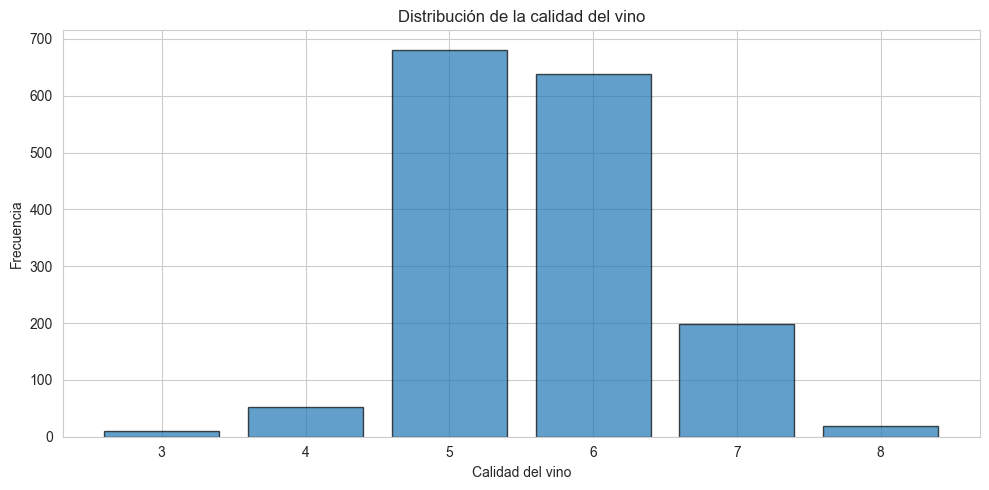

In [44]:
counts = df["quality"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(
    counts.index,
    counts.values,
    width=0.8,
    alpha=0.7,
    edgecolor="black"
)

plt.xlabel("Calidad del vino")
plt.ylabel("Frecuencia")
plt.title("Distribución de la calidad del vino")
plt.xticks(counts.index)

plt.tight_layout()
plt.show()

El dataset contiene **1.599 observaciones** y **12 columnas originales**: 11 variables predictoras relacionadas con la composición fisicoquímica del vino y la variable objetivo `quality`.

Observamos que la distribución de `quality` está claramente concentrada en los valores centrales, especialmente en las calidades 5 y 6. Las calidades extremas, como 3, 4, 7 y 8, aparecen con mucha menor frecuencia. Este punto es importante porque un modelo puede obtener una *accuracy* elevada prediciendo mayoritariamente las clases centrales, aunque tenga dificultades para identificar vinos de calidad baja o alta.


## 3. Exploratory analysis


Comenzamos el análisis exploratorio estudiando las correlaciones entre las variables. El objetivo no es extraer conclusiones causales, sino identificar qué variables parecen estar más asociadas con la calidad del vino.


<Axes: >

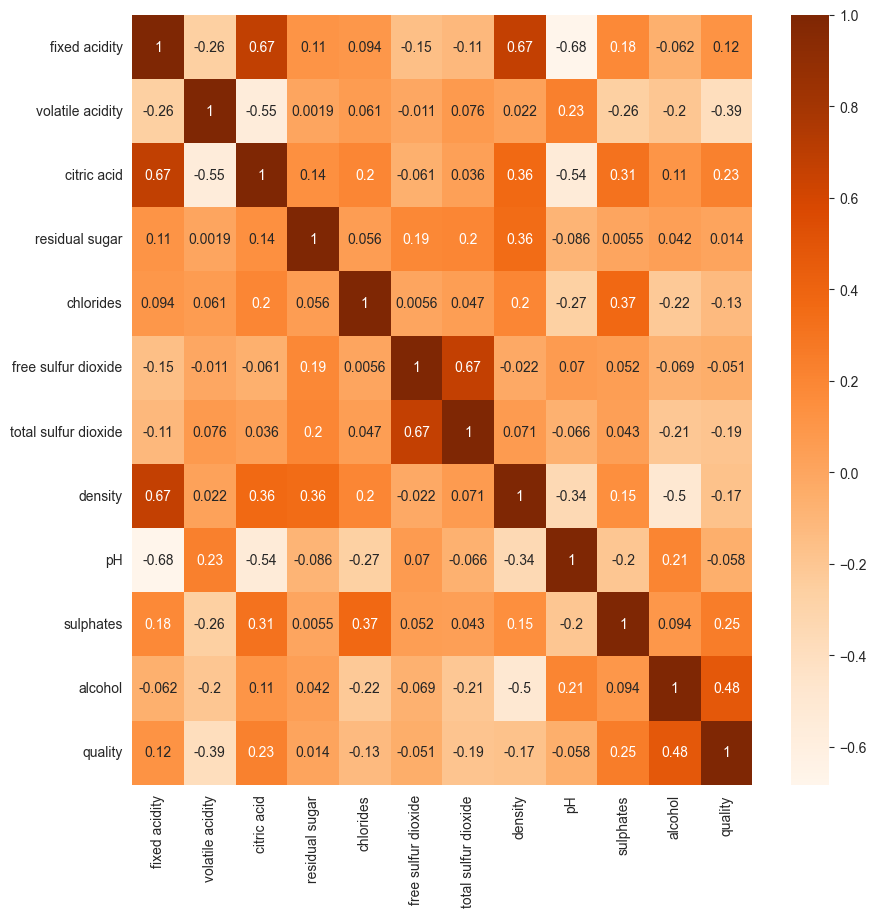

In [45]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot=True, cmap="Oranges")

El mapa de correlaciones muestra que la variable más relacionada con `quality` es alcohol, con una correlación positiva moderada, lo que indica que los vinos con mayor graduación alcohólica tienden a recibir mejores valoraciones. En sentido contrario, `volatile acidity` presenta una correlación negativa con la calidad, por lo que niveles más altos de acidez volátil suelen asociarse con vinos peor valorados. Otras variables como `sulphates` y `citric acid` también tienen relación positiva con la calidad, aunque más débil.

También se observa que no existe una única variable que explique claramente la calidad del vino, ya que la mayoría de correlaciones con `quality` son moderadas o bajas. Además, hay correlaciones fuertes entre algunas variables predictoras, como `fixed acidity`, `citric acid`, `density` y `pH`, así como entre `free sulfur dioxide` y `total sulfur dioxide`, lo que indica cierta redundancia. Por ello, tiene sentido utilizar modelos capaces de combinar varias variables y capturar relaciones no lineales, como **SVM**, **Random Forest** o **KNN**.

La variable `quality` es ordinal y discreta. Por ese motivo, utilizar regresión pura puede generar un problema de interpretación: los modelos producirían valores continuos, aunque las etiquetas reales sean puntuaciones enteras.

Para adaptar el problema a un enfoque de clasificación, transformamos `quality` en una nueva variable `processed_quality` con tres clases:

- `0` — **low quality**: vinos con calidad 3 o 4.  
- `1` — **medium quality**: vinos con calidad 5 o 6.  
- `2` — **high quality**: vinos con calidad 7 u 8.  

Esta transformación conserva el orden natural de la calidad, pero reduce la granularidad del problema para hacerlo más estable y más interpretable.


In [46]:
mask = {
    3: 0,
    4: 0,
    5: 1,
    6: 1,
    7: 2,
    8: 2,
}

df["processed_quality"] = df["quality"]
df["processed_quality"] = df["processed_quality"].map(mask)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,processed_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


Class distribution:
    Low quality: 63 (3.94%)
    Medium quality: 1319 (82.49%)
    High quality: 217 (13.57%)


C:\Users\migue\AppData\Local\Temp\ipykernel_45556\2563207418.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="processed_quality", data=df, palette=["#4C72B0", "#C44E52", "#8d8b55"])


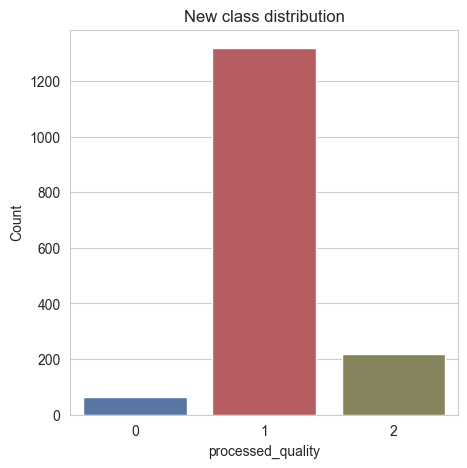

In [47]:
# New class balance
class_count = df["processed_quality"].value_counts()
print("Class distribution:")
print(f"    Low quality: {class_count[0]} ({class_count[0]/df.shape[0]:.2%})")
print(f"    Medium quality: {class_count[1]} ({class_count[1]/df.shape[0]:.2%})")
print(f"    High quality: {class_count[2]} ({class_count[2]/df.shape[0]:.2%})")

plt.figure(figsize=(5,5))
sns.countplot(x="processed_quality", data=df, palette=["#4C72B0", "#C44E52", "#8d8b55"])
plt.title("New class distribution")
plt.ylabel("Count")
plt.show()

Tras agrupar la variable objetivo, el desbalance sigue siendo muy marcado: la clase `medium quality` concentra la mayor parte del dataset, mientras que `low quality` representa una proporción muy pequeña.

Este desequilibrio condiciona todo el proyecto. Un modelo que prediga casi siempre `medium quality` puede obtener una *accuracy* aparentemente alta, pero no sería realmente útil si no identifica correctamente vinos de calidad baja o alta. Por ello, en la fase supervisada no nos quedaremos únicamente con la *accuracy*.


## 4. Preprocessing: split & scale


In [48]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,processed_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


In [49]:
y = df["processed_quality"]
X = df.drop(columns=["processed_quality", "quality"])

Dividimos el dataset en **80% train / 20% test** antes de aplicar cualquier transformación. La partición se realiza con `stratify=y`, lo que mantiene en train y test la misma proporción de clases que en el dataset original.

Es importante aclarar que `stratify` no balancea las clases: si la clase `medium quality` es mayoritaria en el dataset completo, también lo será en train y test. Por ello, en la evaluación utilizaremos métricas adicionales a la *accuracy*, como `balanced_accuracy` y `f1_macro`.

El escalado se realiza con `StandardScaler`. En el análisis no supervisado se aplica sobre las variables predictoras para que PCA y K-Means no queden dominados por las variables con mayor escala. En los modelos supervisados sensibles a la escala, como KNN, Regresión Logística y SVM, el escalado se incluye dentro de un `Pipeline` durante la validación cruzada para evitar *data leakage*.


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Train set: 1279 samples
Test set: 320 samples


In [51]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

## 5. Unsupervised analysis


Antes de entrenar los modelos supervisados, conviene estudiar la estructura interna del conjunto de datos sin utilizar la variable objetivo. Para ello aplicamos **PCA** sobre las variables estandarizadas y, posteriormente, **K-Means** sobre los componentes principales.

Este análisis no pretende predecir la calidad del vino. Su función es descriptiva: permite observar qué combinaciones de variables concentran más variabilidad y si existen grupos naturales de vinos con perfiles fisicoquímicos diferenciados.


In [52]:
sc = StandardScaler()
data_scaled = sc.fit_transform(X)

pca = PCA()
scores = pca.fit_transform(data_scaled)

### 5.1 PCA biplot


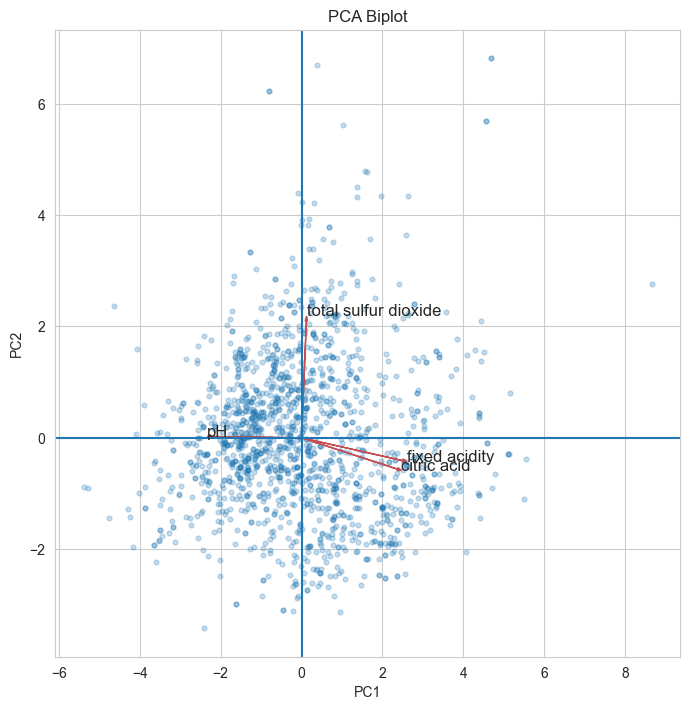

In [53]:
i, j = 0, 1

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

fig, ax = plt.subplots(figsize=(7,7))
ax.scatter(scores[:, i], scores[:, j], alpha=0.25, s=12)
ax.set_xlabel(f'PC{i+1}')
ax.set_ylabel(f'PC{j+1}')

scale_x = 0.7 * np.max(np.abs(loadings[:, i]))
scale_y = 0.7 * np.max(np.abs(loadings[:, j]))

magnitudes = np.sqrt(loadings[:, i]**2 + loadings[:, j]**2)
threshold = np.quantile(magnitudes, 0.65)

for idx in range(loadings.shape[0]):
    if magnitudes[idx] >= threshold:
        x = scale_x * loadings[idx, i] * 5
        y = scale_y * loadings[idx, j] * 5
        ax.arrow(0, 0, x, y, head_width=0.1 * max(scale_x, scale_y), length_includes_head=True, color="#C44E52")
        ax.text(x, y, X.columns[idx], fontsize=12)

ax.axhline()
ax.axvline()
plt.tight_layout()
ax.set_title('PCA Biplot')
plt.show()

### 5.2 Explained variance


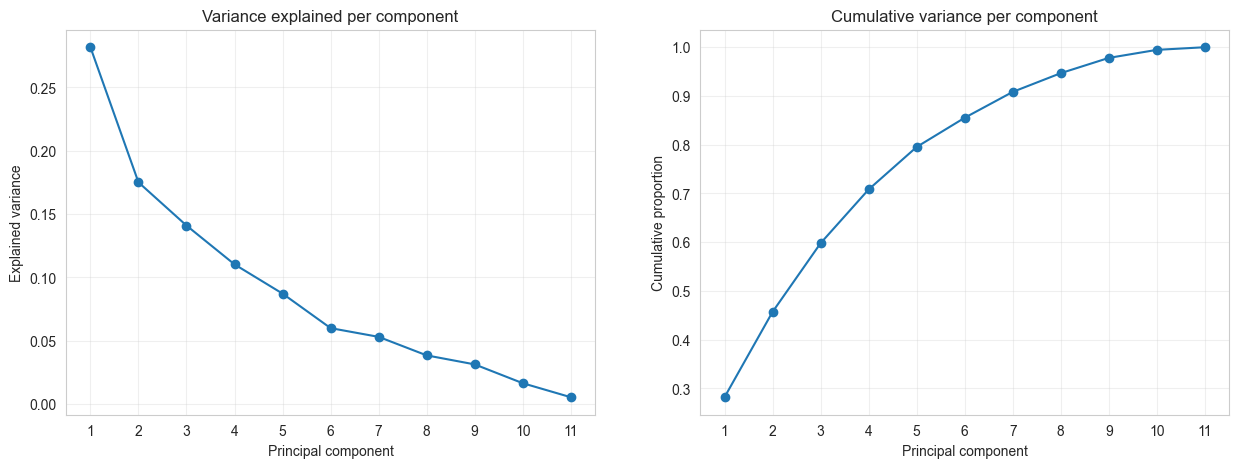

In [54]:
explained_ratio = pca.explained_variance_ratio_
cum_explained_ratio = np.cumsum(explained_ratio)

n_show = len(explained_ratio)
ticks = np.arange(1, n_show + 1)

fig, axes = plt.subplots(1,2, figsize=(15, 5))

axes[0].plot(ticks, explained_ratio, marker="o")
axes[0].set_title("Variance explained per component")
axes[0].set_ylabel("Explained variance")
axes[0].set_xlabel("Principal component")
axes[0].set_xticks(ticks)
axes[0].grid(alpha=0.3)

axes[1].plot(ticks, cum_explained_ratio, marker="o")
axes[1].set_title("Cumulative variance per component")
axes[1].set_xlabel("Principal component")
axes[1].set_ylabel("Cumulative proportion")
axes[1].set_xticks(ticks)
axes[1].grid(alpha=0.3)

### 5.3 Interpretación del PCA

El PCA permite resumir la información de las variables originales en un conjunto de componentes principales. En el biplot, las flechas indican qué variables contribuyen más a la dirección de cada componente.

En este contexto, variables como `fixed acidity`, `citric acid`, `volatile acidity`, `pH`, `sulphates`, `alcohol` y las variables relacionadas con el dióxido de azufre ayudan a explicar las principales diferencias entre los vinos. La interpretación debe hacerse con cautela, porque los componentes no representan variables originales aisladas, sino combinaciones lineales de todas ellas.


## 6. Clustering

Aplicamos K-Means sobre los *scores* obtenidos con PCA para comprobar si aparecen grupos de vinos diferenciados según sus características fisicoquímicas. El número de clusters se estudia mediante dos criterios complementarios: la inercia del método del codo y el *silhouette score*.


In [55]:
k_values = range(2, 8)
inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(scores)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(scores, labels))

results_k = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouettes": silhouettes
})
results_k

,k,inertia,silhouettes
0,2,14330.119811,0.213730
1,3,12629.974592,0.189204
2,4,11294.874527,0.206402
3,5,10155.410717,0.190409
4,6,9363.206701,0.194729
5,7,8644.945888,0.191489


Suggested k by silhouettes method: 2


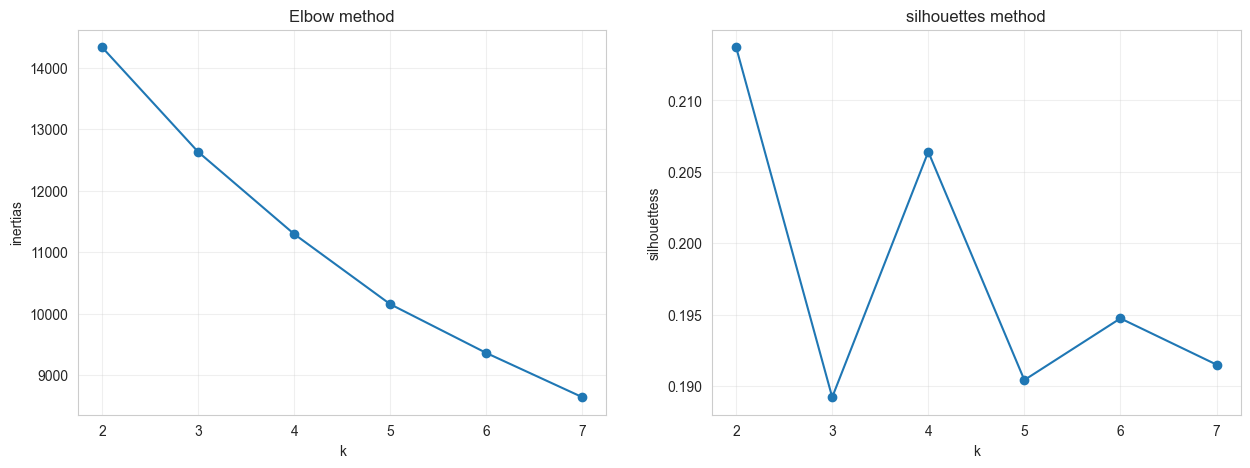

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(results_k["k"], results_k["inertia"], marker="o")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertias")
axes[0].set_xticks(k_values)
axes[0].grid(alpha=0.3)

axes[1].plot(results_k["k"], results_k["silhouettes"], marker="o")
axes[1].set_title("silhouettes method")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouettess")
axes[1].set_xticks(k_values)
axes[1].grid(alpha=0.3)

best_k = int(results_k.loc[results_k["silhouettes"].idxmax(), "k"])
print(f"Suggested k by silhouettes method: {best_k}")

In [57]:
k = best_k
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
cluster_labels = kmeans.fit_predict(scores)

df_clusters = X.copy()
df_clusters["clusters"] = cluster_labels

print("Cluster sizes: ")
print(df_clusters["clusters"].value_counts().sort_index())

Cluster sizes: 
clusters
0     590
1    1009
Name: count, dtype: int64


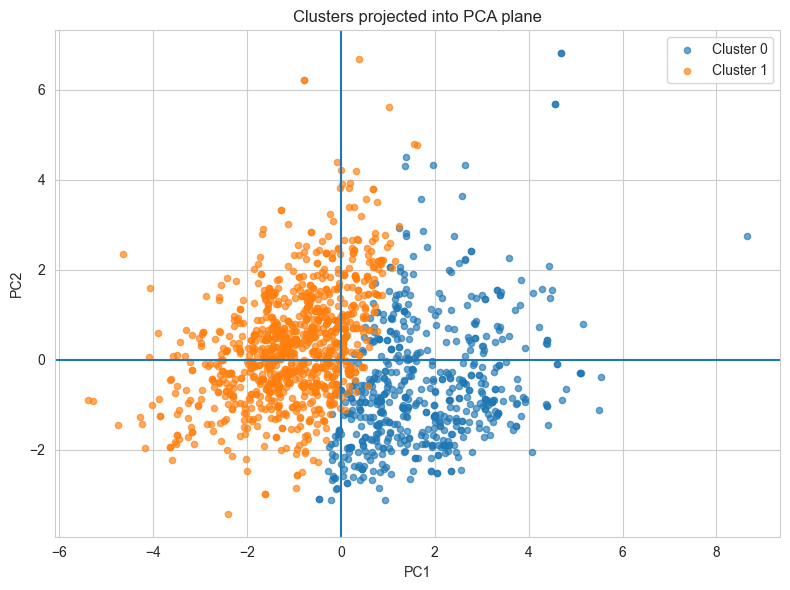

In [58]:
fig, ax = plt.subplots(figsize=(8,6))

for c in sorted(np.unique(cluster_labels)):
    mask = cluster_labels == c
    ax.scatter(scores[mask, 0], scores[mask, 1], alpha=0.65, s=20, label=f'Cluster {c}')

ax.set_title("Clusters projected into PCA plane")
ax.set_ylabel("PC2")
ax.set_xlabel("PC1")
ax.axhline(0)
ax.axvline(0)
ax.legend()
plt.tight_layout()
plt.show()

In [59]:
# Which features differetiates the clusters most?
cluster_profile = df_clusters.groupby("clusters").mean(numeric_only=True)
between_cluster_std = cluster_profile.std(axis=0).sort_values(ascending=False)

print("Features that best differentiate the clusters:")
print(between_cluster_std)

print("\nMean profile per cluster:") 
cluster_profile

Features that best differentiate the clusters:
total sulfur dioxide    7.933311
free sulfur dioxide     2.761949
fixed acidity           1.796371
residual sugar          0.254323
citric acid             0.215045
alcohol                 0.206655
volatile acidity        0.127649
pH                      0.122441
sulphates               0.100951
chlorides               0.013933
density                 0.001056
dtype: float64

Mean profile per cluster:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
clusters,,,,,,,,,,,
0,9.922712,0.413907,0.462881,2.765763,0.099900,13.410169,39.388136,0.997689,3.201847,0.748237,10.607401
1,7.382260,0.594430,0.158761,2.406095,0.080196,17.316155,50.607532,0.996195,3.375005,0.605471,10.315147


El análisis de clusters sugiere dos perfiles principales de vinos. El clúster 0 presenta, en promedio, mayor `fixed acidity`, mayor `citric acid`, mayor `sulphates` y algo más de `alcohol`. En cambio, el clúster 1 muestra mayor `volatile acidity`, mayor `pH` y mayores niveles medios de dióxido de azufre.

Estas diferencias no significan que el clustering prediga directamente la calidad del vino. El análisis es descriptivo: ayuda a identificar grupos con perfiles químicos distintos antes de pasar a los modelos supervisados.


## 7. Supervised Learning

En esta sección comprobamos la capacidad de varios clasificadores para predecir la clase de calidad del vino (`low`, `medium` o `high`). Todos los modelos se comparan sobre el mismo conjunto de test, obtenido mediante una partición estratificada 80/20.

El ajuste de hiperparámetros se realiza únicamente sobre los datos de entrenamiento mediante validación cruzada estratificada. Esta decisión es especialmente importante porque las clases están muy desbalanceadas: la clase `medium quality` representa la gran mayoría de las observaciones.

Para evaluar los modelos utilizamos las siguientes métricas:

- **Accuracy**: porcentaje total de vinos correctamente clasificados. Puede ser engañosa cuando una clase domina el dataset.  
- **Balanced accuracy**: media del *recall* de cada clase. Penaliza que el modelo ignore clases minoritarias.  
- **F1 macro**: media simple del F1-score de cada clase. Todas las clases pesan igual.  
- **F1 weighted**: media ponderada del F1-score según el número de observaciones de cada clase. Puede quedar dominada por `medium quality`.

Por este motivo, en la interpretación final se priorizan `balanced_accuracy` y `f1_macro` frente a la *accuracy* simple.


In [60]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train a model, print metrics and plot its confusion matrix.
    Returns a dict with accuracy, balanced accuracy, F1 macro and F1 weighted."""
    
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    acc = accuracy_score(y_te, pred)
    balanced_acc = balanced_accuracy_score(y_te, pred)
    f1_macro = f1_score(y_te, pred, average="macro")
    f1_weighted = f1_score(y_te, pred, average="weighted")

    print(f"=== {name} ===")
    print(
        f"Accuracy: {acc:.4f}  |  "
        f"Balanced accuracy: {balanced_acc:.4f}  |  "
        f"F1 macro: {f1_macro:.4f}  |  "
        f"F1 weighted: {f1_weighted:.4f}"
    )

    print(classification_report(
        y_te,
        pred,
        target_names=["low quality", "medium quality", "high quality"],
        zero_division=0
    ))
    
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_te, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["low quality", "medium quality", "high quality"],
        yticklabels=["low quality", "medium quality", "high quality"]
    )

    plt.title(f"Confusion matrix — {name}")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

    return {
        "model": name,
        "accuracy": acc,
        "balanced_accuracy": balanced_acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }

In [76]:
results = []

In [62]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

### 7.1 KNN Classifier

KNN clasifica cada observación según las clases de sus vecinos más cercanos. Es un modelo sencillo e intuitivo, pero sensible al escalado de las variables y al desbalance de clases. Por ello se incluye `StandardScaler` dentro del `Pipeline` y se optimizan `n_neighbors`, `weights` y la métrica de distancia.


In [63]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "knn",
        KNeighborsClassifier()
    )
])

param_grid_knn = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]
}

grid_knn = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid_knn,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=4,
    pre_dispatch=4,
    verbose=2
)

# Se pasan los datos sin escalar porque el Pipeline escala dentro de cada fold.
grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_

print("Mejores parámetros:", grid_knn.best_params_)
print("Mejor F1 macro:", grid_knn.best_score_)

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Mejores parámetros: {'knn__n_neighbors': 3, 'knn__p': 2, 'knn__weights': 'distance'}
Mejor F1 macro: 0.5724036653649057


=== KNN ===
Accuracy: 0.8469  |  Balanced accuracy: 0.5353  |  F1 macro: 0.5439  |  F1 weighted: 0.8364
                precision    recall  f1-score   support

   low quality       0.20      0.08      0.11        13
medium quality       0.89      0.92      0.91       264
  high quality       0.62      0.60      0.61        43

      accuracy                           0.85       320
     macro avg       0.57      0.54      0.54       320
  weighted avg       0.83      0.85      0.84       320



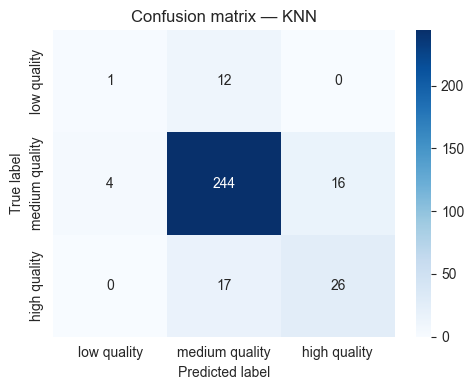

In [77]:
results.append(evaluate_model(
    "KNN",
    best_knn,
    X_train,
    y_train,
    X_test,
    y_test
))

### 7.2 Logistic Regression

La Regresión Logística se utiliza como modelo lineal de referencia para clasificación multiclase. Aunque es más simple que SVM o Random Forest, permite comprobar hasta qué punto las clases pueden separarse mediante relaciones aproximadamente lineales entre las variables.

En la búsqueda de hiperparámetros se prueba también `class_weight="balanced"`, que penaliza más los errores cometidos sobre las clases minoritarias.


In [69]:
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logreg",
        LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=5000
        )
    )
])

param_grid_logreg = [
    {
        "logreg__solver": ["lbfgs"],
        "logreg__penalty": ["l2"],
        "logreg__C": [0.01, 0.1, 1, 10, 100],
        "logreg__class_weight": [None, "balanced"]
    },
    {
        "logreg__solver": ["saga"],
        "logreg__penalty": ["l1", "l2"],
        "logreg__C": [0.01, 0.1, 1, 10, 100],
        "logreg__class_weight": [None, "balanced"]
    }
]

grid_logreg = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid_logreg,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=4,
    pre_dispatch=4,
    verbose=2
)

# Se pasan los datos sin escalar porque el Pipeline escala dentro de cada fold.
grid_logreg.fit(X_train, y_train)

best_logreg = grid_logreg.best_estimator_

print("Mejores parámetros:", grid_logreg.best_params_)
print("Mejor F1 macro:", grid_logreg.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejores parámetros: {'logreg__C': 1, 'logreg__class_weight': None, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}
Mejor F1 macro: 0.48910680816167273


=== Logistic Regression ===
Accuracy: 0.8438  |  Balanced accuracy: 0.4577  |  F1 macro: 0.4676  |  F1 weighted: 0.8168
                precision    recall  f1-score   support

   low quality       0.00      0.00      0.00        13
medium quality       0.87      0.95      0.91       264
  high quality       0.60      0.42      0.49        43

      accuracy                           0.84       320
     macro avg       0.49      0.46      0.47       320
  weighted avg       0.80      0.84      0.82       320



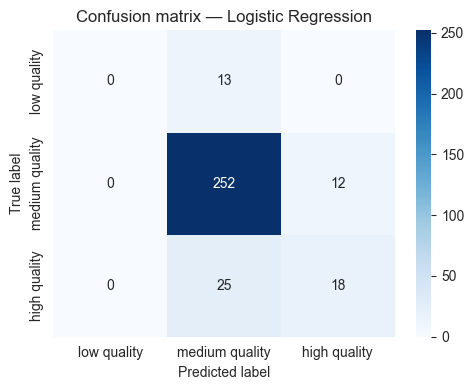

In [78]:
results.append(evaluate_model(
    "Logistic Regression",
    best_logreg,
    X_train,
    y_train,
    X_test,
    y_test
))

### 7.3 Support Vector Machine Classifier

SVM busca fronteras de decisión que separen las clases con el mayor margen posible. Se prueban tanto un kernel lineal como un kernel RBF. El kernel RBF permite capturar relaciones no lineales, algo razonable en este dataset, donde la calidad del vino puede depender de combinaciones complejas entre variables químicas.

También se utiliza `class_weight="balanced"` para reducir el efecto del desbalance de clases.


In [71]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "svm",
        SVC(
            random_state=RANDOM_STATE,
            cache_size=2048,
            class_weight="balanced"
        )
    )
])

param_grid_svm = [
    {
        "svm__kernel": ["linear"],
        "svm__C": [0.1, 1, 10]
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1, 10],
        "svm__gamma": ["scale", 0.01, 0.1]
    }
]

grid_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=4,
    pre_dispatch=4,
    verbose=2
)

# Se pasan los datos sin escalar porque el Pipeline escala dentro de cada fold.
grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_

print("Mejores parámetros:", grid_svm.best_params_)
print("Mejor F1 macro:", grid_svm.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros: {'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Mejor F1 macro: 0.5558300942034198


=== SVM ===
Accuracy: 0.7750  |  Balanced accuracy: 0.6865  |  F1 macro: 0.5892  |  F1 weighted: 0.7975
                precision    recall  f1-score   support

   low quality       0.24      0.46      0.32        13
medium quality       0.94      0.78      0.85       264
  high quality       0.47      0.81      0.60        43

      accuracy                           0.78       320
     macro avg       0.55      0.69      0.59       320
  weighted avg       0.85      0.78      0.80       320



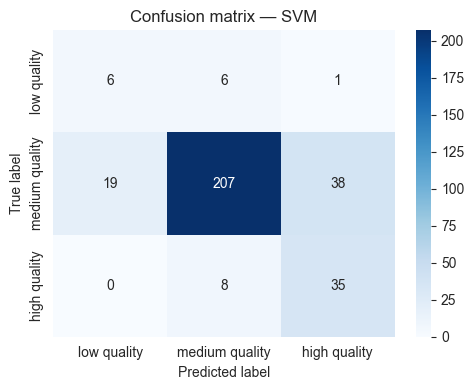

In [79]:
results.append(evaluate_model(
    "SVM",
    best_svm,
    X_train,
    y_train,
    X_test,
    y_test
))

### 7.4 Random Forest Classifier

Random Forest combina múltiples árboles de decisión entrenados sobre subconjuntos aleatorios de los datos y de las variables. Es un modelo robusto para datos tabulares, capaz de capturar relaciones no lineales sin requerir escalado.

En este caso se incluye `class_weight="balanced"` para dar más importancia a las clases minoritarias durante el entrenamiento.


In [74]:
rf_pipeline = Pipeline([
    (
        "rf",
        RandomForestClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced"
        )
    )
])

param_grid_rf = {
    "rf__n_estimators": [100, 200, 300],
    "rf__max_depth": [None, 5, 10, 20],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=4,
    pre_dispatch=4,
    verbose=2
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

print("Mejores parámetros:", grid_rf.best_params_)
print("Mejor F1 macro:", grid_rf.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Mejores parámetros: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}
Mejor F1 macro: 0.5720447816728529


=== Random Forest ===
Accuracy: 0.8562  |  Balanced accuracy: 0.5975  |  F1 macro: 0.5749  |  F1 weighted: 0.8490
                precision    recall  f1-score   support

   low quality       0.50      0.08      0.13        13
medium quality       0.92      0.90      0.91       264
  high quality       0.58      0.81      0.68        43

      accuracy                           0.86       320
     macro avg       0.67      0.60      0.57       320
  weighted avg       0.86      0.86      0.85       320



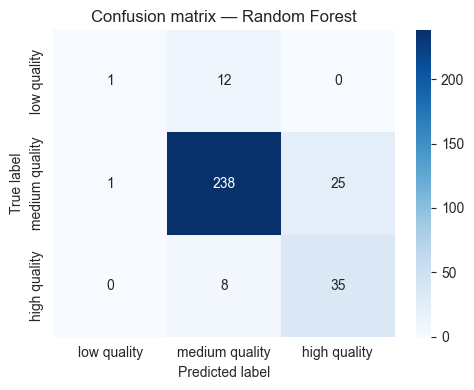

In [80]:
results.append(evaluate_model(
    "Random Forest",
    best_rf,
    X_train,
    y_train,
    X_test,
    y_test
))

## 8. Model Comparison

Una vez entrenados los modelos, comparamos su rendimiento en el conjunto de test. La comparación debe hacerse con cuidado: debido al fuerte desbalance, la *accuracy* puede favorecer a los modelos que predicen mayoritariamente `medium quality`.

Por este motivo, la métrica más relevante para decidir el mejor modelo no es únicamente la *accuracy*, sino especialmente `f1_macro` y `balanced_accuracy`.


In [81]:
results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
results_df


,model,accuracy,balanced_accuracy,f1_macro,f1_weighted
0,SVM,0.775000,0.686528,0.589229,0.797451
1,Random Forest,0.856250,0.597464,0.574941,0.849038
2,KNN,0.846875,0.535272,0.543876,0.836440
3,Logistic Regression,0.843750,0.457717,0.467633,0.816809


La tabla de comparación muestra que no todos los modelos optimizan el mismo tipo de rendimiento. Los modelos con mayor *accuracy* no son necesariamente los mejores para este problema, ya que pueden estar favorecidos por la clase mayoritaria `medium quality`.

Por ello, la comparación principal debe centrarse en `f1_macro` y `balanced_accuracy`. Estas métricas muestran mejor si el modelo está aprendiendo a distinguir las tres clases o si simplemente está concentrando sus predicciones en la categoría más frecuente.


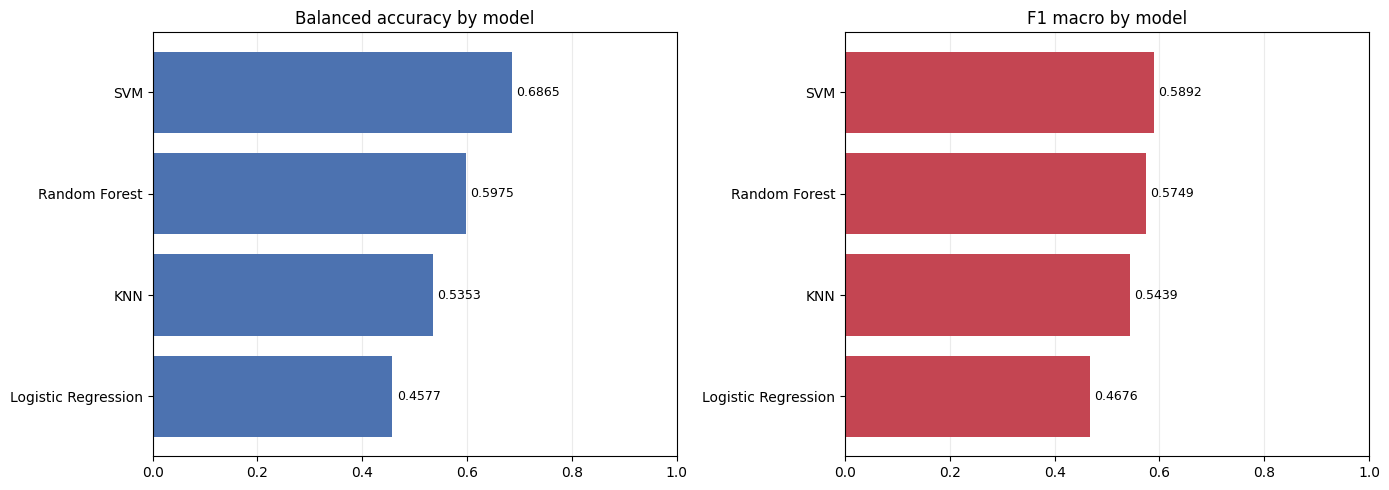

In [84]:
accuracy_df = results_df.sort_values("balanced_accuracy", ascending=False)
f1_df = results_df.sort_values("f1_macro", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(
    accuracy_df["model"],
    accuracy_df["balanced_accuracy"],
    color="#4C72B0"
)
axes[0].set_title("Balanced accuracy by model")
axes[0].set_xlim(0, 1)
axes[0].invert_yaxis()

axes[1].barh(
    f1_df["model"],
    f1_df["f1_macro"],
    color="#C44552"
)
axes[1].set_title("F1 macro by model")
axes[1].set_xlim(0, 1)
axes[1].invert_yaxis()

for ax in axes:
    ax.bar_label(ax.containers[0], fmt="%.4f", padding=3, fontsize=9)
    ax.grid(axis="x", alpha=0.25)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


## 8.1 Interpretación de la comparación

Los resultados muestran que la *accuracy* por sí sola no es suficiente para decidir el mejor modelo. La clase `medium quality` representa más del 80% del dataset, de modo que un clasificador conservador puede obtener una tasa de acierto alta aunque falle en las clases minoritarias.

La Regresión Logística obtiene una *accuracy* elevada, pero presenta un rendimiento muy bajo en la clase `low quality`. Esto indica que el modelo lineal tiende a concentrarse en la clase mayoritaria y tiene dificultades para capturar correctamente los extremos de calidad.

SVM ofrece el mejor equilibrio según `balanced_accuracy` y un F1 macro competitivo. Esto sugiere que el kernel RBF consigue capturar relaciones no lineales entre las variables fisicoquímicas y la clase de calidad. Aunque su *accuracy* global es menor que la de otros modelos, reparte mejor los aciertos entre las tres clases.

Random Forest obtiene la mejor *accuracy* y uno de los mejores valores de F1 macro. Sin embargo, también mantiene dificultades con la clase `low quality`, que cuenta con muy pocas observaciones. Esto confirma que el desbalance del dataset limita la capacidad de cualquier modelo para aprender correctamente la clase minoritaria.

En conjunto, el modelo más adecuado no debe elegirse únicamente por *accuracy*. Para este problema, SVM y Random Forest son las opciones más defendibles, porque ofrecen un mejor compromiso entre rendimiento global y capacidad para reconocer clases minoritarias.


# 9. Conclusiones

**Contexto del dataset.** El conjunto de datos contiene 1.599 vinos descritos mediante 11 variables fisicoquímicas y una puntuación de calidad original entre 3 y 8. La distribución de la calidad está muy concentrada en los valores centrales, especialmente 5 y 6, mientras que las calidades extremas aparecen con poca frecuencia.

**Transformación del problema.** Debido a que `quality` es una variable discreta y ordinal, el problema se reformula como clasificación multiclase. Se crean tres categorías: `low quality`, `medium quality` y `high quality`. Esta decisión mejora la interpretabilidad del proyecto y evita tratar la calidad como una variable continua cuando realmente representa niveles ordenados.

**Análisis exploratorio y no supervisado.** El análisis de correlaciones permite identificar asociaciones entre la calidad y algunas variables químicas, aunque estas relaciones no deben interpretarse como causales. El PCA y el clustering mediante K-Means muestran que existen perfiles de vinos diferenciados principalmente por acidez, ácido cítrico, pH, sulfatos, alcohol y dióxido de azufre. Este análisis es descriptivo y se realiza sin utilizar la variable objetivo.

**Resultados supervisados.** Los modelos se comparan usando una partición estratificada y validación cruzada sobre el conjunto de entrenamiento. Debido al fuerte desbalance, la *accuracy* puede ser engañosa. Por ello, se priorizan `balanced_accuracy` y `f1_macro`, que evalúan mejor el rendimiento en todas las clases.

**Mejor modelo.** SVM y Random Forest son los modelos más sólidos de los evaluados. Random Forest destaca por su rendimiento global, mientras que SVM ofrece un reparto más equilibrado entre clases según `balanced_accuracy`. La Regresión Logística funciona como baseline interpretable, pero muestra limitaciones claras para identificar la clase minoritaria `low quality`.

**Limitaciones.** La principal limitación del proyecto es el fuerte desbalance de clases, especialmente el bajo número de vinos de calidad baja. Esto reduce la capacidad del modelo para aprender patrones fiables en esa categoría. Además, las clases de calidad proceden de una puntuación subjetiva, por lo que puede existir ruido en la etiqueta original.